
# Parte 3 · Transfer learning: fine-tuning con y sin data augmentation

**Visión por Computadora II · CEIA · FIUBA**

En el notebook 02 el backbone estaba congelado y solo se entrenaba un linear head. Acá hacemos **fine-tuning parcial**: se liberan las últimas etapas del backbone y se entrenan junto con el clasificador final.

**Diseño experimental** (2 arquitecturas × 2 configuraciones):

| | Sin augmentation | Con augmentation |
|---|---|---|
| MobileNetV3-Small | `mnv3s_noaug` | `mnv3s_aug` |
| EfficientNet-B0 | `effb0_noaug` | `effb0_aug` |

Se mantienen constantes semilla, split, resolución, optimizador y cantidad de épocas. La mejor época se selecciona por macro-F1 en **val** y **test** se evalúa al final. El entrenamiento usa **CUDA automáticamente si está disponible**, con fallback a CPU.

Se mantiene resolución 160×160, 8 épocas y unfreeze parcial para conservar el protocolo experimental ya utilizado y limitar el costo computacional.


## 0. Configuración

In [2]:

import os
import importlib
from pathlib import Path
import json, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image


HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name.lower() == "notebooks" else HERE

KAGGLE_DIR = PROJECT_ROOT / "data" / "PlantVillage"
DATA_DIR_LOCAL = (
    KAGGLE_DIR / "PlantVillage"
    if (KAGGLE_DIR / "PlantVillage").exists()
    else KAGGLE_DIR
)

if not DATA_DIR_LOCAL.exists():
    raise FileNotFoundError(
        f"No se encontró PlantVillage en {DATA_DIR_LOCAL}. "
        "Ejecutar primero la notebook 01."
    )

# common.py lee esta variable al importarse.
os.environ["PV_DATA_DIR"] = str(DATA_DIR_LOCAL)

import common
importlib.reload(common)
from common import *


QUICK = os.environ.get("FT_QUICK") == "1"
TAG = "quick" if QUICK else "full"

IMG_SIZE_FT = 160
EPOCHS = 1 if QUICK else 8
BATCH_SIZE = 32

# En notebooks de Windows, 0 workers es la opción más estable.
N_WORKERS = 0 if os.name == "nt" else 2

if DEVICE.type == "cpu":
    torch.set_num_threads(min(8, os.cpu_count() or 1))

torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

OUT_DIR = ROOT / "results" / f"finetune_{TAG}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = CACHE_DIR / f"ckpt_{TAG}"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

df, classes = load_split()
short = [c.replace("__", "_").replace("_", " ") for c in classes]

splits = {
    s: df[df.split == s].reset_index(drop=True)
    for s in ["train", "val", "test"]
}

if QUICK:
    splits = {
        s: d.sample(min(len(d), 300), random_state=SEED).reset_index(drop=True)
        for s, d in splits.items()
    }

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print({s: len(d) for s, d in splits.items()},
      "| modo:", TAG,
      "| épocas:", EPOCHS)
print("Dataset:", DATA_DIR)


Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
{'train': 14740, 'val': 2949, 'test': 2949} | modo: full | épocas: 8
Dataset: c:\Users\tolot\Documents\UBA\2026\uba-ai-master\computer-vision2\data\PlantVillage\PlantVillage


## 1. Experimentos

`n_unfreeze` es la cantidad de etapas finales del backbone (`net.features`) que se entrenan. El resto queda *frozen*, con sus BatchNorm en modo `eval` para no alterar sus estadísticas.

In [3]:
EXPERIMENTS = [
    dict(name="mnv3s_noaug", model="mobilenet_v3_small", n_unfreeze=6, augment=False),
    dict(name="mnv3s_aug",   model="mobilenet_v3_small", n_unfreeze=6, augment=True),
    dict(name="effb0_noaug", model="efficientnet_b0",    n_unfreeze=3, augment=False),
    dict(name="effb0_aug",   model="efficientnet_b0",    n_unfreeze=3, augment=True),
]
pd.DataFrame(EXPERIMENTS)

,name,model,n_unfreeze,augment
0,mnv3s_noaug,mobilenet_v3_small,6,False
1,mnv3s_aug,mobilenet_v3_small,6,True
2,effb0_noaug,efficientnet_b0,3,False
3,effb0_aug,efficientnet_b0,3,True



## 2. Entrenamiento

Cada corrida guarda historial, métricas, logits y checkpoint. Una corrida se reutiliza solamente si existen **los tres artefactos necesarios** (`.json`, `.pt` y `_logits.npz`); si alguno falta, se vuelve a ejecutar para evitar estados incompletos.

`common.py` mueve modelo y batches a CUDA cuando está disponible. Los checkpoints se guardan en CPU para que puedan cargarse también en máquinas sin GPU.


In [4]:

def run_experiment(exp):
    res_path = OUT_DIR / f"{exp['name']}.json"
    ckpt_path = CKPT_DIR / f"{exp['name']}.pt"
    logits_path = OUT_DIR / f"{exp['name']}_logits.npz"

    if res_path.exists() and ckpt_path.exists() and logits_path.exists():
        print(f"[{exp['name']}] ya entrenado, se carga de disco")
        with open(res_path, encoding="utf-8") as f:
            return json.load(f)

    print(
        f"\n===== {exp['name']} "
        f"({exp['model']}, unfreeze={exp['n_unfreeze']}, augment={exp['augment']}) =====",
        flush=True,
    )

    train_tf, eval_tf_ft = make_transforms(IMG_SIZE_FT, exp["augment"])

    def make_loader(data, transform, shuffle):
        return DataLoader(
            PlantDataset(data, transform=transform),
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            num_workers=N_WORKERS,
            persistent_workers=(N_WORKERS > 0),
            pin_memory=(DEVICE.type == "cuda"),
        )

    train_loader = make_loader(splits["train"], train_tf, True)
    val_loader = make_loader(splits["val"], eval_tf_ft, False)
    test_loader = make_loader(splits["test"], eval_tf_ft, False)

    net = finetune_model(
        exp["model"],
        len(classes),
        exp["n_unfreeze"],
    ).to(DEVICE)

    n_train = sum(p.numel() for p in net.parameters() if p.requires_grad)

    log_path = OUT_DIR / f"{exp['name']}.log"
    log_path.write_text("", encoding="utf-8")

    t0 = time.time()
    history, best_state = fit(
        net,
        train_loader,
        val_loader,
        EPOCHS,
        log_path=log_path,
        device=DEVICE,
    )
    minutes = (time.time() - t0) / 60

    net.load_state_dict(best_state)
    torch.save(best_state, ckpt_path)

    val_logits, yv = predict(net, val_loader, device=DEVICE)
    test_logits, yt = predict(net, test_loader, device=DEVICE)

    np.savez(
        logits_path,
        val=val_logits,
        test=test_logits,
        y_val=yv,
        y_test=yt,
    )

    out = {
        **exp,
        "trainable_params_M": n_train / 1e6,
        "train_minutes": minutes,
        "history": history,
        "best_epoch": int(np.argmax([h["val_macro_f1"] for h in history]) + 1),
        **{f"val_{k}": v for k, v in metrics(yv, val_logits.argmax(1)).items()},
        **{f"test_{k}": v for k, v in metrics(yt, test_logits.argmax(1)).items()},
    }

    with open(res_path, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2)

    print(
        f"[{exp['name']}] test macro-F1 {out['test_macro_f1']:.4f} | "
        f"test acc {out['test_accuracy']:.4f} | {minutes:.1f} min"
    )

    return out


runs = {e["name"]: run_experiment(e) for e in EXPERIMENTS}



===== mnv3s_noaug (mobilenet_v3_small, unfreeze=6, augment=False) =====
ep 1/8 | train_loss 0.3116 | val_loss 0.1005 | val_acc 0.9641 | val_macro_f1 0.9623 | 65s
ep 2/8 | train_loss 0.0704 | val_loss 0.0795 | val_acc 0.9773 | val_macro_f1 0.9762 | 61s
ep 3/8 | train_loss 0.0389 | val_loss 0.0522 | val_acc 0.9864 | val_macro_f1 0.9846 | 62s
ep 4/8 | train_loss 0.0160 | val_loss 0.0693 | val_acc 0.9803 | val_macro_f1 0.9795 | 61s
ep 5/8 | train_loss 0.0089 | val_loss 0.0538 | val_acc 0.9875 | val_macro_f1 0.9864 | 62s
ep 6/8 | train_loss 0.0070 | val_loss 0.0546 | val_acc 0.9875 | val_macro_f1 0.9863 | 67s
ep 7/8 | train_loss 0.0032 | val_loss 0.0472 | val_acc 0.9881 | val_macro_f1 0.9861 | 57s
ep 8/8 | train_loss 0.0031 | val_loss 0.0480 | val_acc 0.9871 | val_macro_f1 0.9846 | 58s
[mnv3s_noaug] test macro-F1 0.9791 | test acc 0.9875 | 8.2 min

===== mnv3s_aug (mobilenet_v3_small, unfreeze=6, augment=True) =====
ep 1/8 | train_loss 0.4648 | val_loss 0.1579 | val_acc 0.9434 | val_macro_

## 3. Resultados

In [5]:
rows = []
for name, r in runs.items():
    rows.append({"corrida": name, "modelo": r["model"], "augmentation": r["augment"],
                 "params entrenables (M)": round(r["trainable_params_M"], 2), "mejor época": r["best_epoch"],
                 "val macro-F1": r["val_macro_f1"], "test accuracy": r["test_accuracy"],
                 "test balanced acc": r["test_balanced_acc"], "test macro-F1": r["test_macro_f1"],
                 "min": round(r["train_minutes"], 1)})
summary = pd.DataFrame(rows).set_index("corrida")

# Referencia: linear probe (frozen backbone) del notebook 02, sin ponderar
lp_path = ROOT / "results" / "linear_probe.csv"
if lp_path.exists():
    lp = pd.read_csv(lp_path); lp = lp[~lp["loss ponderada"]].set_index("modelo")
    summary["linear probe test macro-F1 (nb 02)"] = summary["modelo"].map(lp["test_macro_f1"])
summary.to_csv(OUT_DIR / "summary.csv")
summary.round(4)

,modelo,augmentation,params entrenables (M),mejor época,val macro-F1,test accuracy,test balanced acc,test macro-F1,min,linear probe test macro-F1 (nb 02)
corrida,,,,,,,,,,
mnv3s_noaug,mobilenet_v3_small,False,1.39,5,0.9864,0.9875,0.9792,0.9791,8.2,0.9605
mnv3s_aug,mobilenet_v3_small,True,1.39,8,0.9844,0.9898,0.9834,0.9849,14.4,0.9605
effb0_noaug,efficientnet_b0,False,3.17,5,0.9955,0.9946,0.9917,0.9928,9.1,0.9591
effb0_aug,efficientnet_b0,True,3.17,8,0.9931,0.9953,0.9955,0.9952,14.9,0.9591


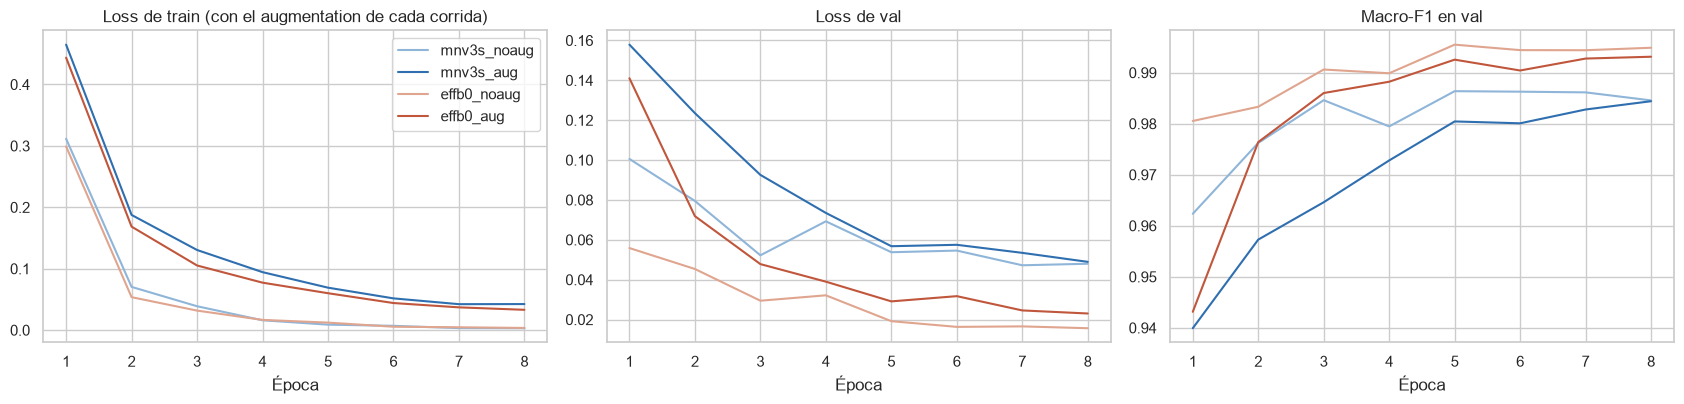

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
colors = {"mnv3s_noaug": "#8fb5d9", "mnv3s_aug": "#2f6fb0", "effb0_noaug": "#e0a58f", "effb0_aug": "#c0563b"}
for name, r in runs.items():
    h = pd.DataFrame(r["history"])
    axes[0].plot(h.epoch, h.train_loss, color=colors[name], label=name)
    axes[1].plot(h.epoch, h.val_loss, color=colors[name], label=name)
    axes[2].plot(h.epoch, h.val_macro_f1, color=colors[name], label=name)
axes[0].set_title("Loss de train (con el augmentation de cada corrida)"); axes[1].set_title("Loss de val")
axes[2].set_title("Macro-F1 en val")
for ax in axes: ax.set_xlabel("Época")
axes[0].legend(); plt.tight_layout(); plt.show()


**Interpretación:** el fine-tuning mejora claramente el baseline de linear probe. En la corrida previa, el augmentation modificó muy poco el desempeño sobre test limpio; su utilidad principal se evalúa en la notebook 04, donde se estudia la robustez ante cambios de iluminación, rotación, escala y blur. La selección final sigue basándose en validación, no en test.


## 4. Análisis por clase

F1 por clase en **test** para las 4 corridas. El accuracy global esconde qué enfermedades cambian con el augmentation o con el modelo.

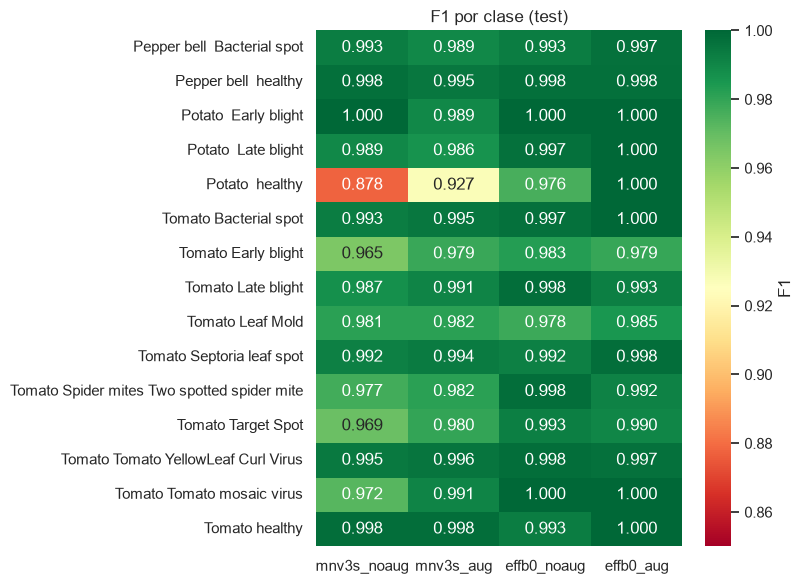

In [7]:
def per_class_f1(name):
    z = np.load(OUT_DIR / f"{name}_logits.npz")
    rep = classification_report(z["y_test"], z["test"].argmax(1), labels=range(len(classes)),
                                target_names=short, output_dict=True, zero_division=0)
    return pd.Series({c: rep[c]["f1-score"] for c in short})

f1_table = pd.DataFrame({n: per_class_f1(n) for n in runs})
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(f1_table, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.85, vmax=1.0, ax=ax, cbar_kws={"label": "F1"})
ax.set_title("F1 por clase (test)"); plt.tight_layout(); plt.show()

## 5. Errores del mejor modelo (test)

Mejor corrida por macro-F1 en val: effb0_noaug


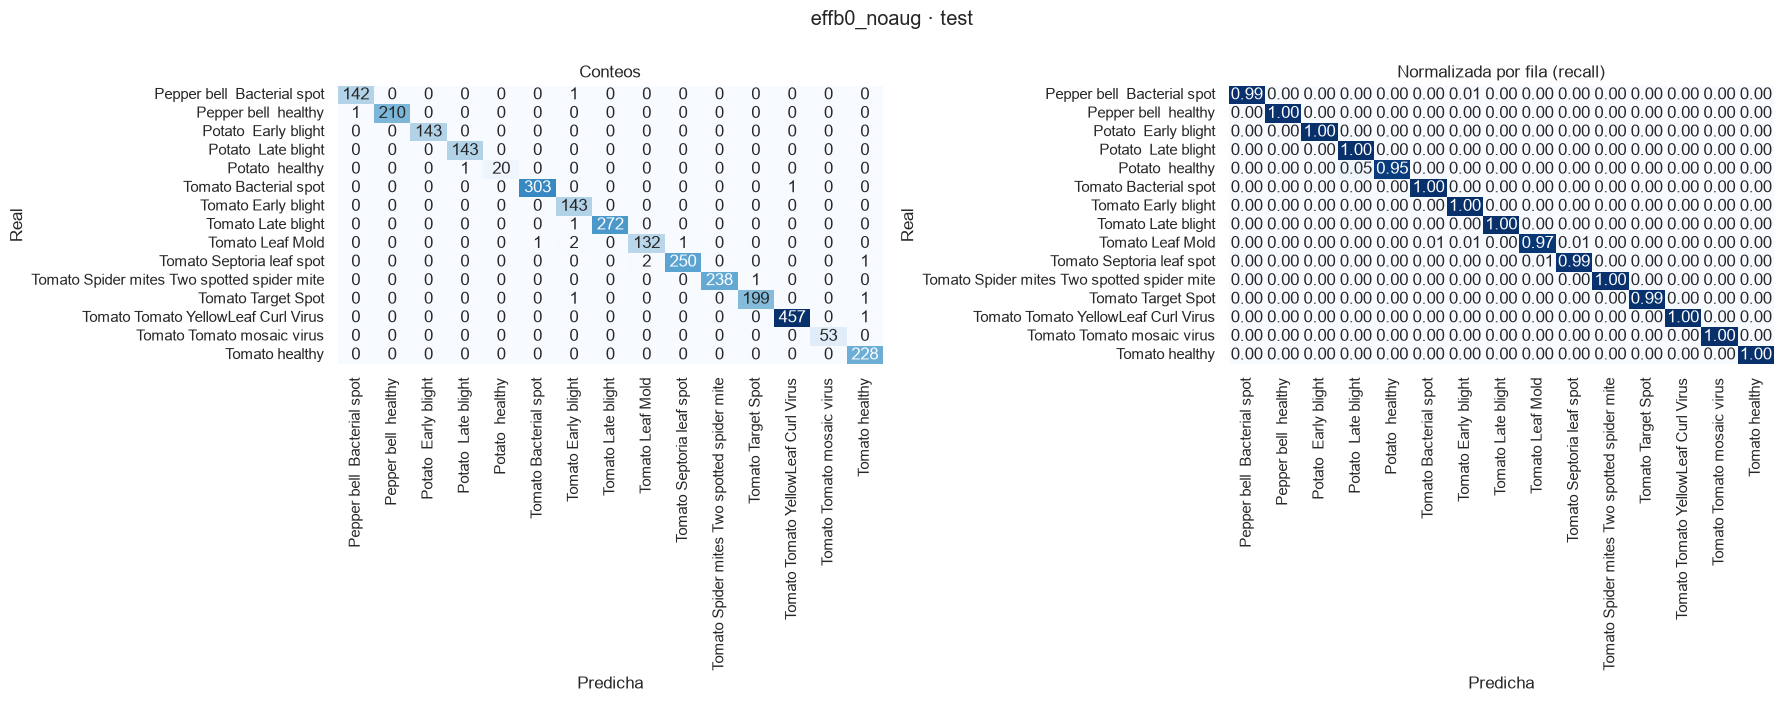

,real,predicha,errores
0,Tomato Leaf Mold,Tomato Early blight,2
1,Tomato Septoria leaf spot,Tomato Leaf Mold,2
2,Pepper bell Bacterial spot,Tomato Early blight,1
3,Pepper bell healthy,Pepper bell Bacterial spot,1
4,Potato healthy,Potato Late blight,1
5,Tomato Bacterial spot,Tomato Tomato YellowLeaf Curl Virus,1
6,Tomato Late blight,Tomato Early blight,1
7,Tomato Leaf Mold,Tomato Bacterial spot,1


In [8]:
BEST = summary["val macro-F1"].idxmax()
print("Mejor corrida por macro-F1 en val:", BEST)
z = np.load(OUT_DIR / f"{BEST}_logits.npz")
yt, yp = z["y_test"], z["test"].argmax(1)
cm = confusion_matrix(yt, yp, labels=range(len(classes)))
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[0], cbar=False)
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[1], cbar=False)
axes[0].set_title("Conteos"); axes[1].set_title("Normalizada por fila (recall)")
for ax in axes: ax.set_xlabel("Predicha"); ax.set_ylabel("Real"); ax.tick_params(axis="x", rotation=90)
plt.suptitle(f"{BEST} · test", y=1.0); plt.tight_layout(); plt.show()

pairs = [(short[i], short[j], int(cm[i, j])) for i in range(len(short)) for j in range(len(short)) if i != j and cm[i, j] > 0]
pd.DataFrame(sorted(pairs, key=lambda t: -t[2])[:8], columns=["real", "predicha", "errores"])

16 errores de 2949 imágenes de test


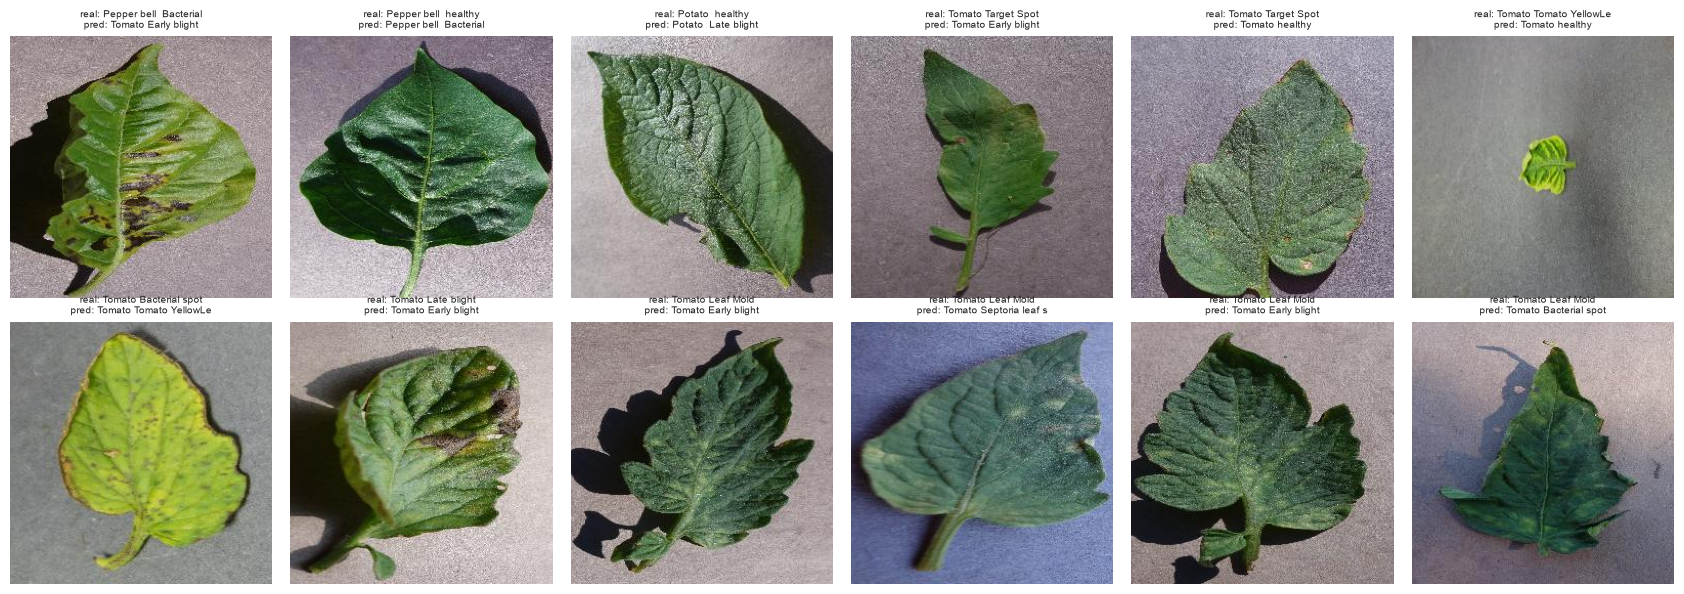

In [9]:
wrong = np.where(yt != yp)[0]
print(f"{len(wrong)} errores de {len(yt)} imágenes de test")
show = wrong[:12]
fig, axes = plt.subplots(2, 6, figsize=(17, 6))
for ax in axes.ravel(): ax.axis("off")
for ax, i in zip(axes.ravel(), show):
    r = splits["test"].iloc[i]
    ax.imshow(Image.open(DATA_DIR / r["relpath"]).convert("RGB"))
    ax.set_title(f"real: {short[yt[i]][:22]}\npred: {short[yp[i]][:22]}", fontsize=7)
plt.tight_layout(); plt.show()


El análisis visual de los errores permite detectar si las confusiones corresponden a síntomas parecidos o a condiciones de adquisición de la imagen. En la corrida previa, los errores fueron pocos y se concentraron principalmente entre enfermedades de tomate visualmente relacionadas. La notebook 04 complementa este análisis con perturbaciones controladas.



## 6. Próximo paso

Evaluar los checkpoints de `cache/ckpt_full/` bajo perturbaciones controladas del conjunto de test. El objetivo es medir si el **data augmentation mejora la robustez** aunque su efecto sobre el test limpio sea pequeño.
